In [5]:
import numpy as np
from matplotlib import pyplot as plt
import qutip as qt
from qutip import *
from scipy.integrate import quad
from scipy.linalg import eigh
from scipy import interpolate as interp

In [2]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

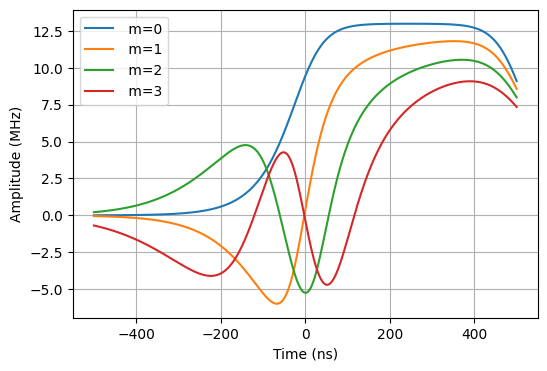

In [3]:

def f(t, m, kappa):
    return xi_m(t, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
t_vals = np.linspace(-500, 500, 501)

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


calc the state of a quantum system

In [6]:
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a

T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

e_ops = []
options = Options(store_states=True, store_final_state=False, nsteps=1000, progress_bar=True)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [11]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 251
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator = f_prime_vals + (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)

def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))

def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

In [15]:

psi0 = (g0 + f0).unit()

args = {
    "center": 0.0,
    "fogi_mode": 3,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}


def L_func(t, args):
    return np.sqrt(kappa_r) * a

def L_dag_func(t, args):
    return np.sqrt(kappa_r) * a.dag()

H = [
    H_fogi,
    [H_d, g_time], [H_d.dag(), g_time_conj],
]
def total_c_op(t, args):
    c_op = np.sqrt(kappa_r) * a
    return c_op

c_ops = [
    total_c_op
]
result = qt.mesolve(H, psi0, tgrid, c_ops, e_ops=[a.dag() * a], args=args, options=options, progress_bar=True)
n_meso = result.expect[0]

# ---------------------------
# correlation_2op_2tでG1(t1, t2)
# ---------------------------
# G1 = qt.correlation_2op_2t(
#     H,
#     psi0,
#     tgrid,
#     tgrid,
#     c_ops,
#     a.dag(),
#     a,
#     args=args,
#     options=options
# )


10.0%. Run time:   0.07s. Est. time left: 00:00:00:00
20.0%. Run time:   0.13s. Est. time left: 00:00:00:00
30.0%. Run time:   0.19s. Est. time left: 00:00:00:00
40.0%. Run time:   0.24s. Est. time left: 00:00:00:00
50.0%. Run time:   0.29s. Est. time left: 00:00:00:00
60.0%. Run time:   0.34s. Est. time left: 00:00:00:00
70.0%. Run time:   0.39s. Est. time left: 00:00:00:00
80.0%. Run time:   0.44s. Est. time left: 00:00:00:00
90.0%. Run time:   0.49s. Est. time left: 00:00:00:00
100.0%. Run time:   0.55s. Est. time left: 00:00:00:00
Total run time:   0.55s


calc the output field from the autocorrelation

In [13]:
# from Arjan-san

def fourPanelPlot(tList, d1, d2, d3, d4, title1, title2, title3, title4):
    extent = [tList[0], tList[-1], tList[0], tList[-1]]
    
    fig, axes = plt.subplots(2,2, figsize=(12,12))
    im00 = axes[0][0].imshow(d1, extent=extent, origin='lower', cmap='magma')
    axes[0][0].set_title(title1)
    axes[0][0].set_xlim(0, 10)
    axes[0][0].set_ylim(0, 10)
    axes[0][0].set_xlabel(r'$\kappa t_2$')
    axes[0][0].set_ylabel(r'$\kappa t_1$')
    im10 = axes[1][0].imshow(d2, extent=extent, origin='lower', cmap='magma')
    axes[1][0].set_title(title2)
    axes[1][0].set_xlim(0, 10)
    axes[1][0].set_ylim(0, 10)
    axes[1][0].set_xlabel(r'$\kappa t_2$')
    axes[1][0].set_ylabel(r'$\kappa t_1$')
    im01 = axes[0][1].imshow(d3, extent=extent, origin='lower', cmap='magma')
    axes[0][1].set_title(title3)
    axes[0][1].set_xlim(0, 10)
    axes[0][1].set_ylim(0, 10)
    axes[0][1].set_xlabel(r'$\kappa t_2$')
    axes[0][1].set_ylabel(r'$\kappa t_1$')
    im11 = axes[1][1].imshow(d4, extent=extent, origin='lower', cmap='magma')
    axes[1][1].set_title(title4)
    axes[1][1].set_xlim(0, 10)
    axes[1][1].set_ylim(0, 10)
    axes[1][1].set_xlabel(r'$\kappa t_2$')
    axes[1][1].set_ylabel(r'$\kappa t_1$')
    
    plt.colorbar(im00, ax=axes[0][0])
    plt.colorbar(im01, ax=axes[0][1])
    plt.colorbar(im10, ax=axes[1][0])
    plt.colorbar(im11, ax=axes[1][1])
    
    plt.show()

def transformMatrixK(AB, BdAd):
    #code by Marek Pechal
    #Note I need to know both A(t+tau)B(t) AND Bd(t)Ad(t+tau) for this
    #ABNew = np.zeros(np.shape(AB), dtype='complex64')
    
    if AB is BdAd:
        print('AB is BdAd')
        for i in range(AB.shape[0]):
            AB[i, i:] = AB[i, :AB.shape[1]-i]
            AB[i, :i] = AB[:i, i].conjugate()
        return AB, AB
    
    else:
        print('AB is not BdAd')
        for i in range(AB.shape[0]):
            AB[i,i:] = AB[i, :AB.shape[1]-i]
            BdAd[i,i:] = BdAd[i, :BdAd.shape[1]-i]
            AB[i, :i] = BdAd[:i, i].conjugate()
            BdAd[i, :i] = AB[:i, i].conjugate()
        return AB, BdAd

finished ada calc
finished adc calc
finished cda calc
finished cdc calc


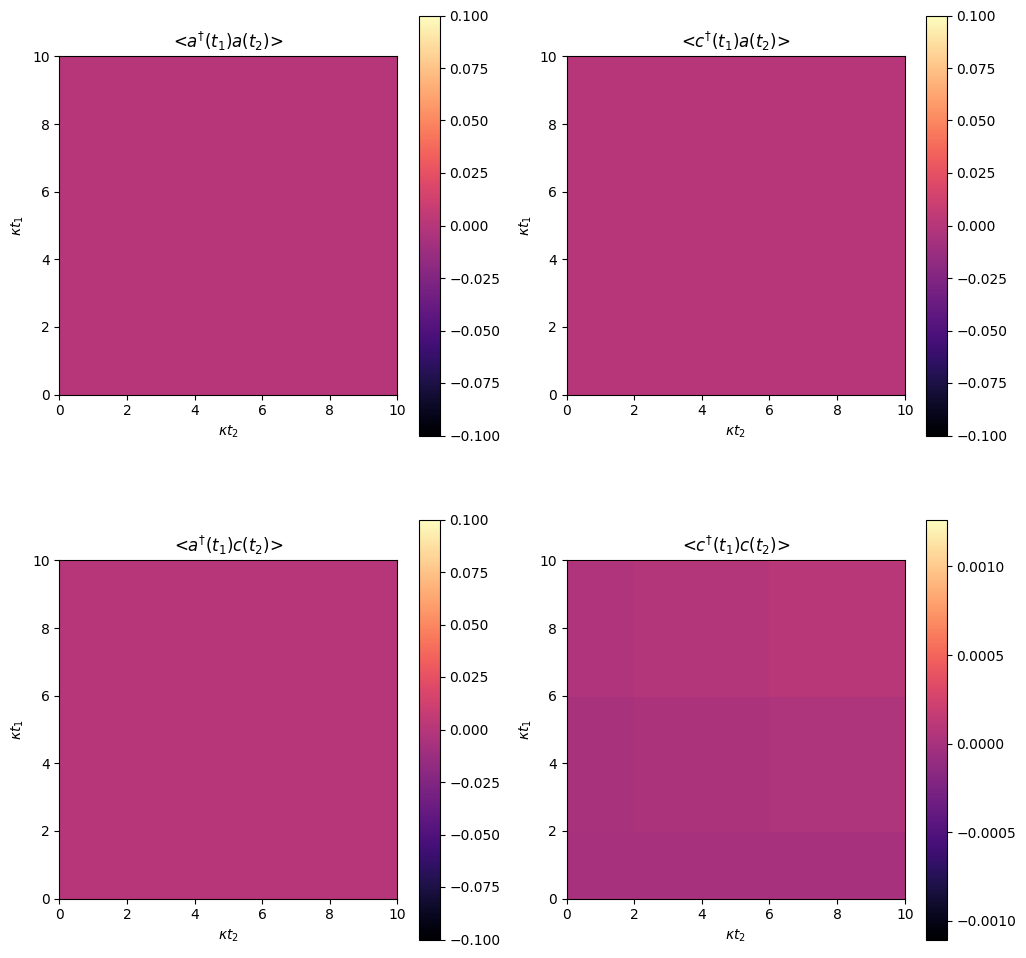

In [16]:
ada = qt.correlation_2op_2t(H, psi0, tgrid, tgrid, c_ops, vc.dag(), vc, args=args, reverse=True)
print("finished ada calc")
adc = qt.correlation_2op_2t(H, psi0, tgrid, tgrid, c_ops, vc.dag(), a, args=args, reverse=True) 
print("finished adc calc")
cda = qt.correlation_2op_2t(H, psi0, tgrid, tgrid, c_ops, a.dag(), vc, args=args, reverse=True)
print("finished cda calc")
cdc = qt.correlation_2op_2t(H, psi0, tgrid, tgrid, c_ops, a.dag(), a, args=args, reverse=True)
print("finished cdc calc")
    
fourPanelPlot(tgrid, np.real(ada), np.real(adc), np.real(cda), np.real(cdc),
              r'<$a^{\dagger}(t_1)a(t_2)$>', r'<$a^{\dagger}(t_1)c(t_2)$>', r'<$c^{\dagger}(t_1)a(t_2)$>', r'<$c^{\dagger}(t_1)c(t_2)$>')

In [17]:
#prefactors
ID = np.ones((len(tgrid), len(tgrid)))
ID1 = np.ones(len(tgrid))
kappas2 = kappa_r*ID
kappag = np.outer(np.sqrt(kappa_r)*ID1, [g_u(t, args) for t in tgrid])
gkappa = np.outer([np.conjugate(g_u(t, args)) for t in tgrid], np.sqrt(kappa_r)*ID1)
gg = np.outer([g_u(t, args) for t in tgrid], [np.conjugate(g_u(t, args)) for t in tgrid])

LdL = gg*ada  + kappag*adc + gkappa*cda + kappas2*cdc

AB is not BdAd
AB is not BdAd
AB is not BdAd
AB is not BdAd


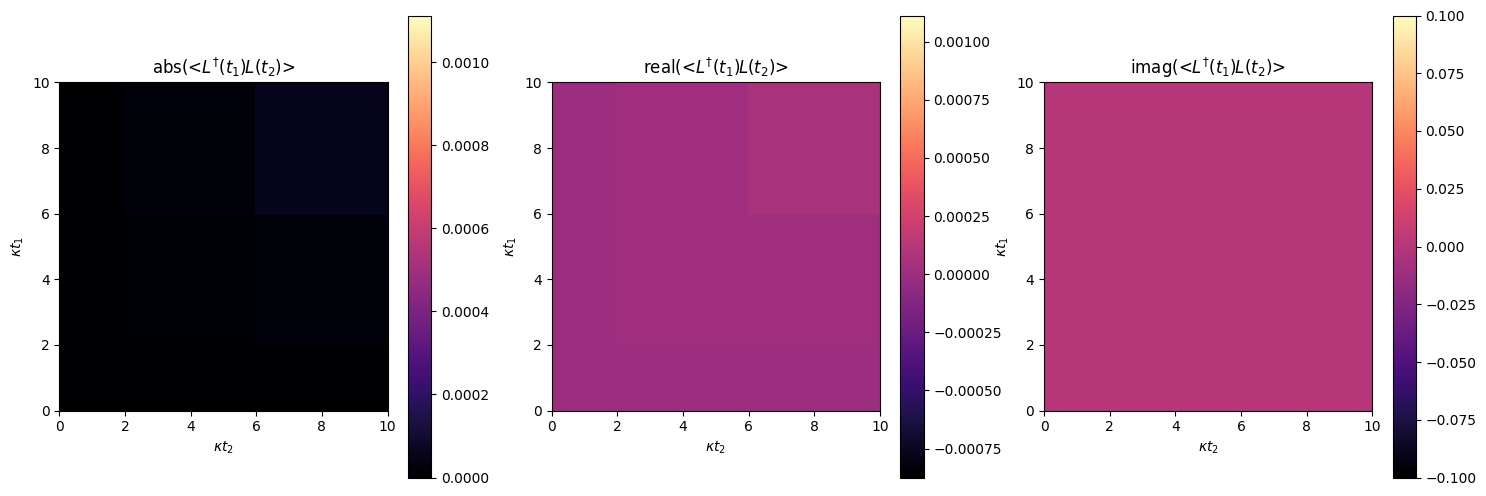

In [18]:
#Use the commutation relations to get aad, ccd
adac = ada.conjugate()
cdcc = cdc.conjugate()

adar = transformMatrixK(1*ada, adac)[0]
cdcr = transformMatrixK(1*cdc, cdcc)[0]
adcr = transformMatrixK(1*adc, 1*cda.conjugate())[0]
cdar = transformMatrixK(1*cda, 1*adc.conjugate())[0]
LdLr =  gg*adar +  gkappa*adcr +  kappag*cdar + kappas2*cdcr

extent = [tgrid[0], tgrid[-1], tgrid[0], tgrid[-1]]
fig2, axes2 = plt.subplots(1,3, figsize=(18,6))
im20 = axes2[0].imshow(np.abs(LdLr), extent=extent, origin='lower', cmap='magma')
axes2[0].set_title(r'abs(<$L^{\dagger}(t_1)L(t_2)$>')
axes2[0].set_xlim(0, 10)
axes2[0].set_ylim(0, 10)
axes2[0].set_xlabel(r'$\kappa t_2$')
axes2[0].set_ylabel(r'$\kappa t_1$')
plt.colorbar(im20, ax=axes2[0])
im21 = axes2[1].imshow(np.real(LdLr), extent=extent, origin='lower', cmap='magma')
axes2[1].set_title(r'real(<$L^{\dagger}(t_1)L(t_2)$>')
axes2[1].set_xlim(0, 10)
axes2[1].set_ylim(0, 10)
axes2[1].set_xlabel(r'$\kappa t_2$')
axes2[1].set_ylabel(r'$\kappa t_1$')
plt.colorbar(im21, ax=axes2[1])
im22 = axes2[2].imshow(np.imag(LdLr), extent=extent, origin='lower', cmap='magma')
axes2[2].set_title(r'imag(<$L^{\dagger}(t_1)L(t_2)$>')
axes2[2].set_xlim(0, 10)
axes2[2].set_ylim(0, 10)
axes2[2].set_xlabel(r'$\kappa t_2$')
axes2[2].set_ylabel(r'$\kappa t_1$')
plt.colorbar(im22, ax=axes2[2])


c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


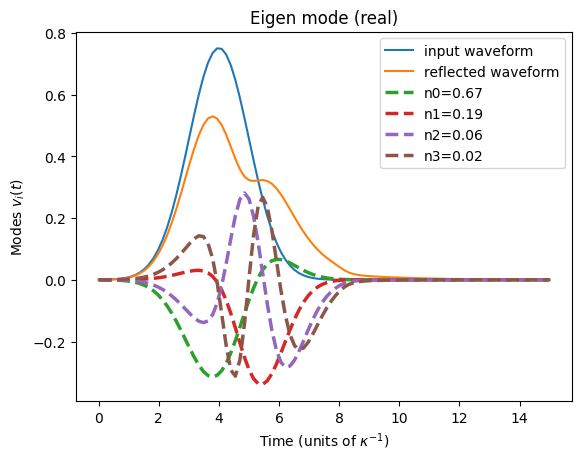

In [116]:
eigvals, eigvecs = eigh(LdLr, type=1)

#Sort by size of eigenvalue
sortOrder = np.argsort(np.real(eigvals))[::-1]
valsSorted = eigvals[sortOrder]
vecsSorted = eigvecs[:, sortOrder]
eigvals_normalized = valsSorted / np.sum(np.abs(valsSorted)) 

fig, axes = plt.subplots()
axes.plot(tList, uGauss(tList, driveFuncArgs), label='input waveform')
axes.plot(tList, np.sqrt(np.diagonal(LdLr)), label='reflected waveform')
for i in range(4):
    eigenmode = interp.interp1d(tList, vecsSorted[:,i], kind='cubic', bounds_error=False, fill_value=0)
    axes.plot(tList, np.real(eigenmode(tList)), lw=2.5, linestyle='--', label='n'+str(i)+'='+str(np.round(eigvals_normalized[i], 2)))
axes.set_title(r'Eigen mode (real)')
axes.set_xlabel(r'Time (units of $\kappa^{-1}$)')
axes.set_ylabel(r'Modes $v_i(t)$')
axes.legend()